# Classical Pipeline

## Transcription

### Load Model

In [2]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

processor = TrOCRProcessor.from_pretrained("Sprakbanken/trocr_smi_pred_synth")
model = VisionEncoderDecoderModel.from_pretrained("Sprakbanken/trocr_smi_pred_synth")


### Decode Image

In [3]:
from PIL import Image
from matplotlib import pyplot as plt

def transcribe_image(image_path):
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values
    generated_ids = model.generate(pixel_values)
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return generated_text

###### Single Img

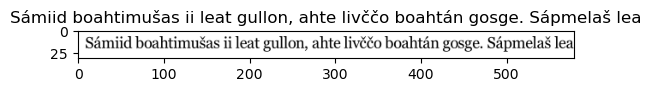

In [8]:
# Single Img
image_path = "./test_data/test6.png"
generated_text = transcribe_image(image_path)

plt.imshow(Image.open(image_path))
plt.title(generated_text)
plt.show()

###### Multiple Imgs

In [9]:
# images = ["./test_data/test1.jpg", "./test_data/test2.jpg", "./test_data/test3.png", "./test_data/test4.png"]
# rows, cols = 1, len(images)

# fig = plt.figure(figsize=(10, 10))
# for i in range(1, rows * cols + 1):
#     transcribed_text = transcribe_image(images[i-1])
#     fig.add_subplot(rows,cols , i)
#     plt.imshow(Image.open(images[i-1]).convert("RGB"), cmap="gray")
#     plt.title(transcribed_text)
#     plt.axis(False);

## Translation

In [10]:
import requests

url = 'https://api.tartunlp.ai/translation/v2' # https://github.com/TartuNLP/translation-api
body = {
  "text": generated_text,  # "SÃ¡mediggi lea sÃ¡miid Ã¡lbmotvÃ¡lljen orgÃ¡na Norggas.!",
  "src": "sme",
  "tgt": "eng",
  "domain": "general",
  "application": "Documentation UI"
}

translation_response = requests.post(url, json = body)

print(f"Translating: {generated_text}")
print(f"Translation: {translation_response.json()['result']}")

Translating: Sámiid boahtimušas ii leat gullon, ahte livččo boahtán gosge. Sápmelaš lea
Translation: It has not been reported that the Sámi have come from anywhere.
